# 📥 DESCARGA AUTOMÁTICA DE DATASETS

⚠️ **IMPORTANTE**: Este notebook requiere datasets de imágenes que no están incluidos en GitHub.

Los archivos necesarios se descargarán automáticamente desde Google Drive al ejecutar la siguiente celda.

## Archivos requeridos:
- `train_images/` (~1.2 GB) - Imágenes de entrenamiento (25,000+ archivos)
- `defect_and_no_defect.csv` - Metadata de defectos
- `train.csv` - Dataset de entrenamiento
- `test.csv` - Dataset de prueba
- `resnet-weights.weights.h5` (198 MB) - Pesos del modelo ResNet
- `resunet-segmentation-weights.weights.h5` (90 MB) - Pesos del modelo ResUNet

**Instrucciones**:
1. Ejecuta la celda siguiente para descargar automáticamente
2. La descarga puede tardar varios minutos (~1.5 GB total)
3. Continúa con el resto del notebook normalmente

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import cv2
from skimage import io
import tensorflow as tf
from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, normalize
import os
%matplotlib inline


In [ ]:
# ============================================================================
# 📥 DESCARGA AUTOMÁTICA DE DATASETS DESDE GOOGLE DRIVE
# ============================================================================

import os
import gdown
import zipfile
from pathlib import Path

# ID de la carpeta de Google Drive para Maintenance Department
# Nota: Esta es una subcarpeta dentro de DS_APLICADO_NEGOCIOS
FOLDER_ID = "1zFAW-VEQ-pXyBZfo9CGEpBjIGe-DJWCn"  # Carpeta raíz DS_APLICADO_NEGOCIOS

print("=" * 70)
print("  📦 CONFIGURACIÓN DE DATASETS - MAINTENANCE DEPARTMENT")
print("=" * 70)

# Archivos y carpetas necesarios
required_items = [
    'train_images',  # Carpeta con 25,000+ imágenes
    'defect_and_no_defect.csv',
    'train.csv',
    'test.csv',
    'resnet-weights.weights.h5',
    'resunet-segmentation-weights.weights.h5'
]

# Verificar archivos existentes
print("\n🔍 Verificando archivos existentes...")
all_exist = True
for item in required_items:
    if os.path.exists(item):
        if os.path.isdir(item):
            num_files = len(list(Path(item).rglob('*')))
            print(f"   ✅ {item}/ - {num_files} archivos")
        else:
            size_mb = os.path.getsize(item) / (1024 * 1024)
            print(f"   ✅ {item} - {size_mb:.2f} MB")
    else:
        print(f"   ❌ {item} - No encontrado")
        all_exist = False

# Descargar si falta algún archivo
if not all_exist:
    print("\n📥 Descargando archivos desde Google Drive...")
    print("   Carpeta: DS_APLICADO_NEGOCIOS/6_Maintenance")
    print("   ⚠️ ADVERTENCIA: Esta descarga puede tardar varios minutos (~1.5 GB)")
    
    try:
        # Descargar carpeta completa
        gdown.download_folder(
            id=FOLDER_ID,
            quiet=False,
            use_cookies=False
        )
        
        # Extraer train_images.zip si existe
        if os.path.exists('train_images.zip') and not os.path.exists('train_images'):
            print("\n📂 Extrayendo train_images.zip (esto puede tardar varios minutos)...")
            with zipfile.ZipFile('train_images.zip', 'r') as zip_ref:
                zip_ref.extractall('.')
            print("✅ train_images/ extraído correctamente")
            os.remove('train_images.zip')
            print("🧹 train_images.zip eliminado")
        
        print("\n✅ Descarga completada!")
        
    except Exception as e:
        print(f"\n❌ Error durante la descarga: {e}")
        print("\n⚠️ SOLUCIÓN MANUAL:")
        print(f"   1. Ve a: https://drive.google.com/drive/folders/{FOLDER_ID}")
        print("   2. Navega a la subcarpeta '6_Maintenance'")
        print("   3. Descarga los archivos manualmente")
        print("   4. Colócalos en esta carpeta")
else:
    print("\n✅ Todos los archivos ya están presentes")

# Verificación final
print("\n" + "=" * 70)
print("  📋 ESTADO FINAL DE ARCHIVOS")
print("=" * 70)
for item in required_items:
    if os.path.exists(item):
        if os.path.isdir(item):
            num_files = len(list(Path(item).rglob('*')))
            print(f"   ✅ {item}/ - {num_files} archivos")
        else:
            size_mb = os.path.getsize(item) / (1024 * 1024)
            print(f"   ✅ {item} - {size_mb:.2f} MB")
    else:
        print(f"   ❌ {item} - NO ENCONTRADO")

print("\n📊 Puedes continuar con el resto del notebook.\n")

In [9]:
# Datos que contienen imágenes con defectos con máscara de segmentación
from pathlib import Path
defect_class_mask_df = pd.read_csv(Path.cwd() / '6. Maintenance Department/train.csv')


In [10]:
# Datos que contienen imágenes con y sin defectos
from pathlib import Path
all_images_df = pd.read_csv(Path.cwd() / '6. Maintenance Department/defect_and_no_defect.csv')


In [11]:
defect_class_mask_df

,ImageId,ClassId,EncodedPixels
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...
3,f0dc068a8.jpg,3,159207 26 159412 77 159617 128 159822 179 1600...
4,00d639396.jpg,3,229356 17 229595 34 229850 36 230105 37 230360...
...,...,...,...
5743,c12842f5e.jpg,3,88 23 342 29 596 34 850 39 1105 44 1361 46 161...
5744,2222a03b3.jpg,3,63332 4 63587 11 63841 20 64096 27 64351 35 64...
5745,b43ea2c01.jpg,1,185024 7 185279 11 185535 12 185790 13 186045 ...
5746,1bc37a6f4.jpg,3,303867 1 304122 3 304376 6 304613 3 304630 9 3...


In [12]:
all_images_df

,ImageID,label
0,0002cc93b.jpg,1
1,0007a71bf.jpg,1
2,000a4bcdd.jpg,1
3,000f6bf48.jpg,1
4,0014fce06.jpg,1
...,...,...
12992,0482ee1d6.jpg,0
12993,04802a6c2.jpg,0
12994,03ae2bc91.jpg,0
12995,04238d7e3.jpg,0


In [13]:
defect_class_mask_df['mask'] = defect_class_mask_df['ClassId'].map(lambda x: 1)

In [14]:
defect_class_mask_df.head(50)

,ImageId,ClassId,EncodedPixels,mask
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...,1
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...,1
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...,1
3,f0dc068a8.jpg,3,159207 26 159412 77 159617 128 159822 179 1600...,1
4,00d639396.jpg,3,229356 17 229595 34 229850 36 230105 37 230360...,1
5,17d02873a.jpg,3,254980 43 255236 127 255492 211 255748 253 256...,1
6,47b5ab1bd.jpg,3,128976 8 129230 12 129484 16 129739 23 129995 ...,1
7,a6ecee828.jpg,3,179011 27 179126 73 179259 39 179375 80 179497...,1
8,11aaf18e2.jpg,3,303235 2 303489 7 303743 9 303997 11 304181 2 ...,1
9,cdf669a1f.jpg,4,310246 11 310499 25 310753 28 311007 31 311262...,1


Text(0.5, 1.0, 'Number of images per class')

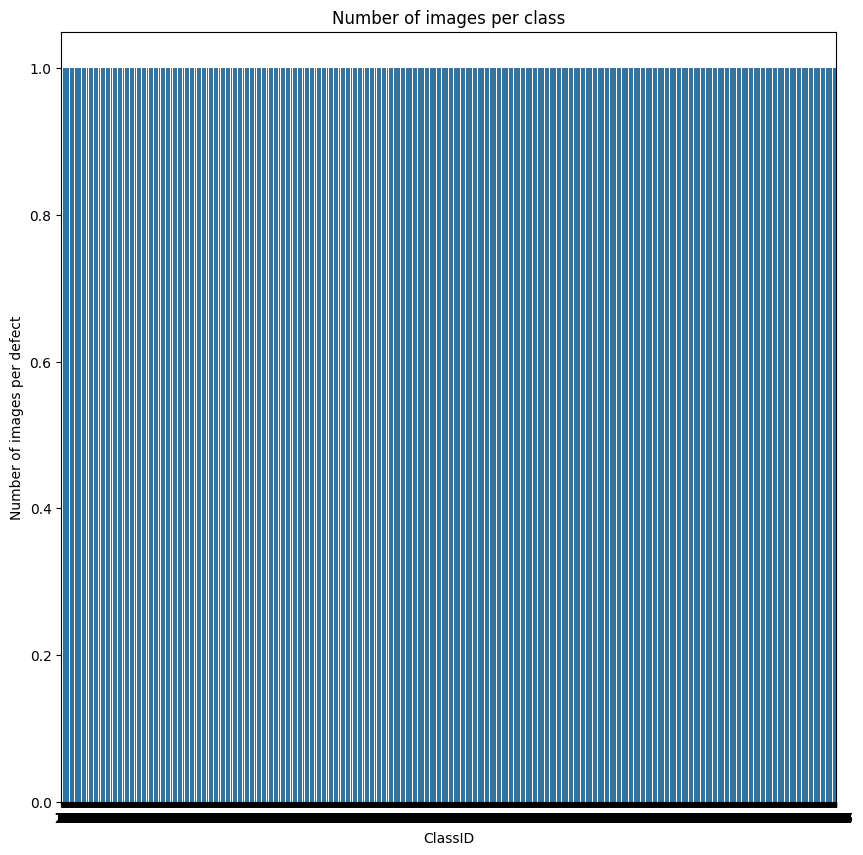

In [10]:
plt.figure(figsize=(10,10))
sns.countplot(defect_class_mask_df['ClassId'])
plt.ylabel('Number of images per defect')
plt.xlabel('ClassID')
plt.title('Number of images per class')

In [15]:
# Algunas imágenes están clasificadas con más de un defecto, exploremos esto con más detalle
# tenemos una imagen con 3 tipos de defectos
# tenemos 272 imágenes con 2 tipos de defectos
# tenemos 5201 imágenes con 1 tipo de defecto
defect_type = defect_class_mask_df.groupby(['ImageId'])['mask'].sum()


In [16]:
defect_type


ImageId
0002cc93b.jpg    1
0007a71bf.jpg    1
000a4bcdd.jpg    1
000f6bf48.jpg    1
0014fce06.jpg    1
                ..
ffcf72ecf.jpg    1
fff02e9c5.jpg    1
fffe98443.jpg    1
ffff4eaa8.jpg    1
ffffd67df.jpg    1
Name: mask, Length: 5474, dtype: int64

In [17]:
defect_type.value_counts()

mask
1    5201
2     272
3       1
Name: count, dtype: int64

Text(0.5, 1.0, 'Number of defects in image')

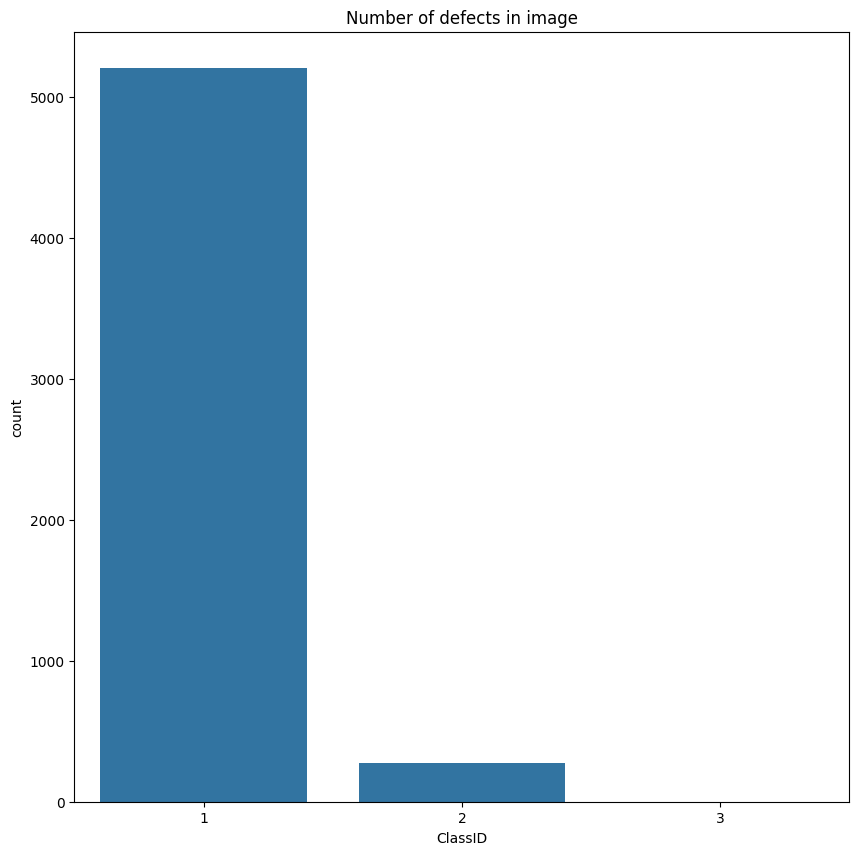

In [14]:
plt.figure(figsize=(10,10))
sns.barplot(x = defect_type.value_counts().index, y = defect_type.value_counts() )
plt.xlabel('ClassID')
plt.title('Number of defects in image')

In [18]:
defect_class_mask_df.shape

(5748, 4)

In [19]:
all_images_df.shape

(12997, 2)

In [20]:
# Contemos imágenes con y sin defectos
all_images_df.label.value_counts()

label
1    7095
0    5902
Name: count, dtype: int64

Text(0.5, 1.0, 'Defect and non-defect images')

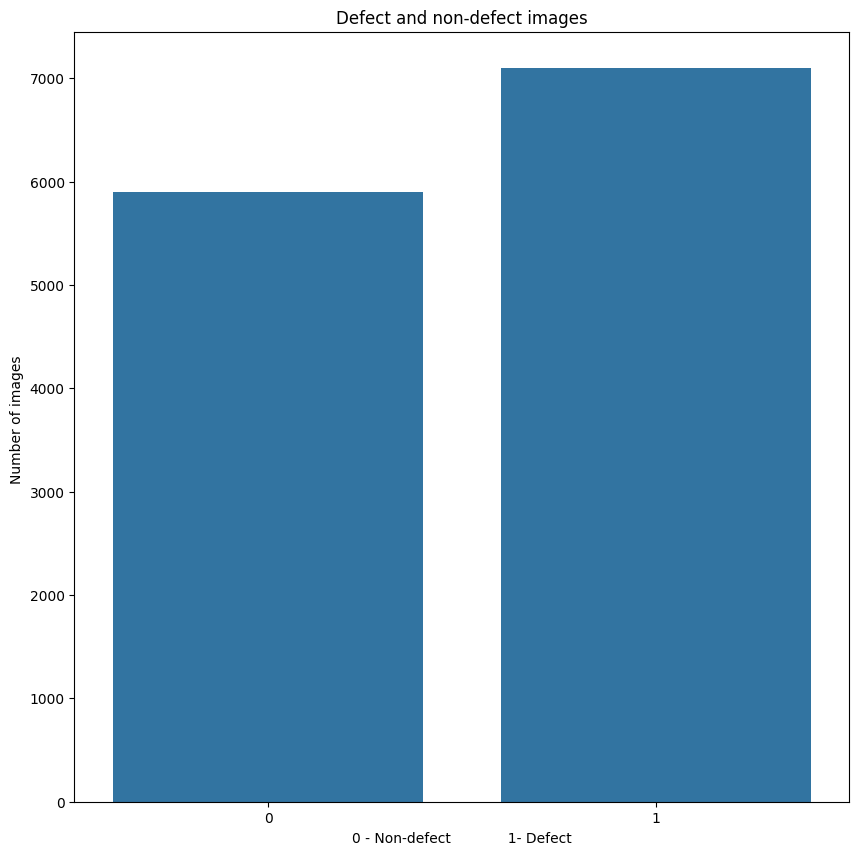

In [21]:
plt.figure(figsize=(10,10))
sns.barplot(x = all_images_df.label.value_counts().index, y = all_images_df.label.value_counts() )
plt.ylabel('Number of images ')
plt.xlabel('0 - Non-defect             1- Defect')
plt.title('Defect and non-defect images')

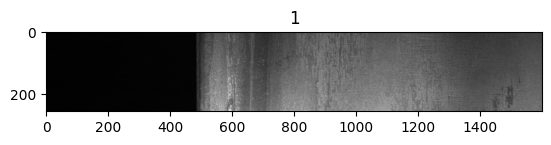

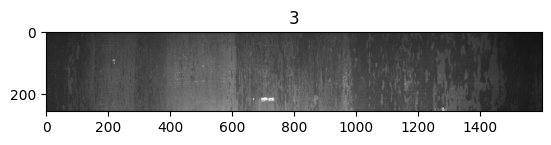

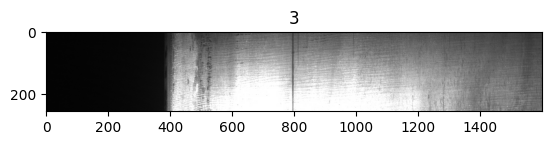

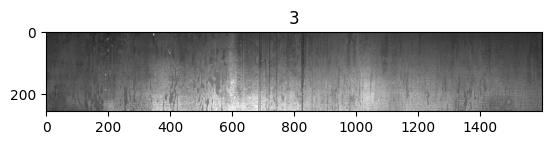

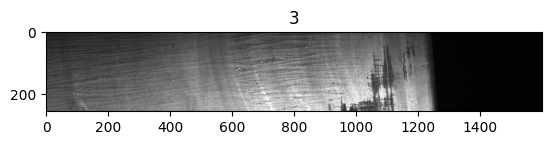

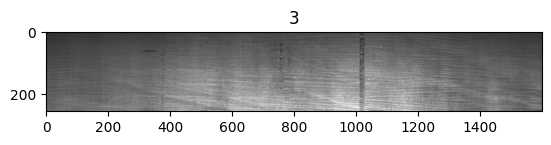

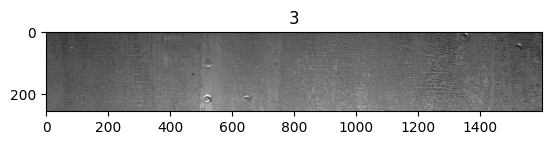

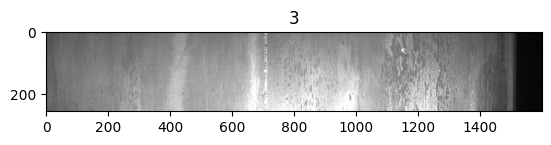

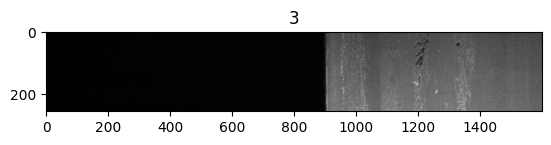

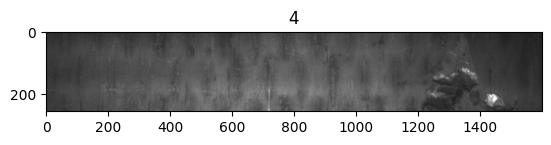

In [22]:
# Visualizar imágenes con defectos junto con sus etiquetas correspondientes
from pathlib import Path
# Las imágenes son de 256 x 1600
train_dir = Path.cwd() / '6. Maintenance Department/train_images'

for i in range(10):
  # Especificar el path de las imágenes a partir de su ID de imagen
  img = io.imread(os.path.join(train_dir, defect_class_mask_df.ImageId[i]))
  plt.figure()
  plt.title(defect_class_mask_df.ClassId[i])
  plt.imshow(img)


In [23]:
# El archivo de Utilities contiene el código para rle2mask, mask2rle, función de pérdida personalizada y generador de datos personalizados
# dado que los datos proporcionados para la segmentación están en formato RLE (run length encoded), usaremos la siguiente función para convertir el RLE a máscara.
# podemos convertir la máscara nuevamente a RLE para evaluar el rendimiento del modelo (accuracy).
# El código fuente para estas funciones proviene de: https://www.kaggle.com/paulorzp/rle-functions-run-lenght-encode-decode
from utilities import rle2mask , mask2rle

In [24]:
defect_class_mask_df

,ImageId,ClassId,EncodedPixels,mask
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...,1
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...,1
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...,1
3,f0dc068a8.jpg,3,159207 26 159412 77 159617 128 159822 179 1600...,1
4,00d639396.jpg,3,229356 17 229595 34 229850 36 230105 37 230360...,1
...,...,...,...,...
5743,c12842f5e.jpg,3,88 23 342 29 596 34 850 39 1105 44 1361 46 161...,1
5744,2222a03b3.jpg,3,63332 4 63587 11 63841 20 64096 27 64351 35 64...,1
5745,b43ea2c01.jpg,1,185024 7 185279 11 185535 12 185790 13 186045 ...,1
5746,1bc37a6f4.jpg,3,303867 1 304122 3 304376 6 304613 3 304630 9 3...,1


In [25]:
# Intentemos usar rle2mask en un imagen de prueba
image_index = 20 #20 30
mask = rle2mask(defect_class_mask_df.EncodedPixels[image_index], img.shape[0], img.shape[1])
mask.shape

(256, 1600)

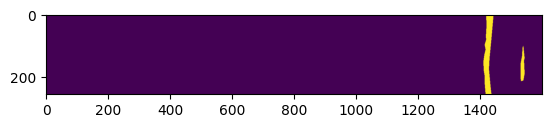

In [26]:
# Veamos la máscara
plt.imshow(mask)

(256, 1600, 3)

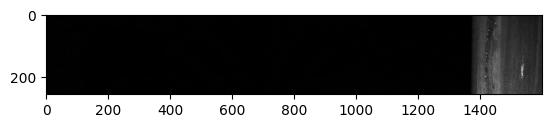

In [27]:
img = io.imread(os.path.join(train_dir, defect_class_mask_df.ImageId[image_index]))
plt.imshow(img)
img.shape

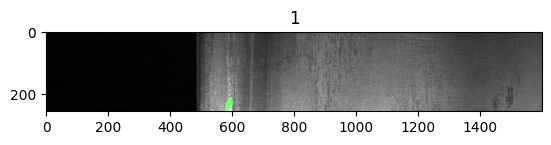

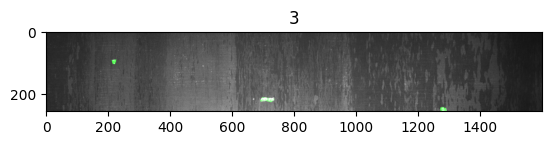

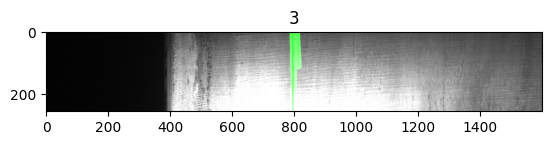

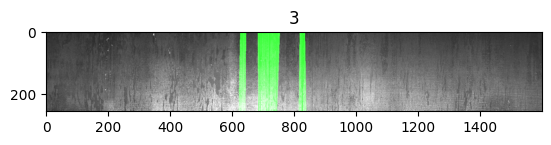

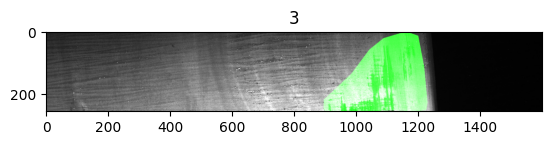

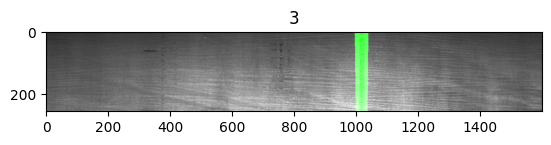

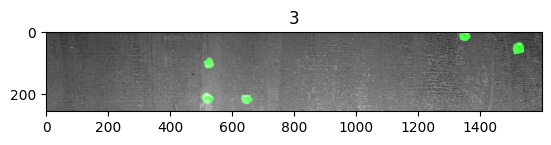

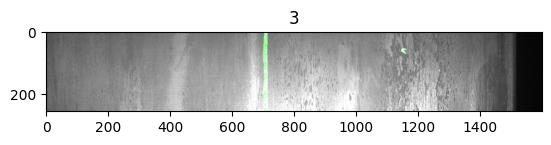

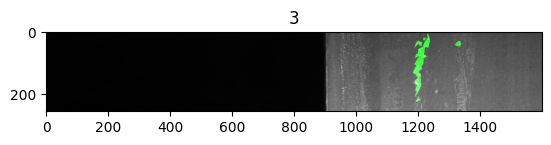

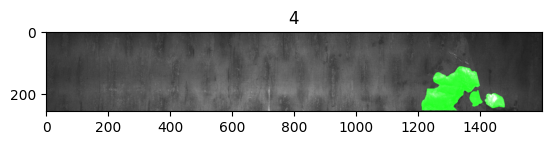

In [28]:
for i in range(10):

  # Read the images using opencv and converting to rgb format
  img = io.imread(os.path.join(train_dir, defect_class_mask_df.ImageId[i]))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # Get the mask for the image from rle
  mask = rle2mask(defect_class_mask_df.EncodedPixels[i], img.shape[0], img.shape[1])

  # Let's color the pixels with values = 1
  img[mask == 1,1] = 255
  plt.figure()
  plt.imshow(img)
  plt.title(defect_class_mask_df.ClassId[i])


In [29]:
all_images_df

,ImageID,label
0,0002cc93b.jpg,1
1,0007a71bf.jpg,1
2,000a4bcdd.jpg,1
3,000f6bf48.jpg,1
4,0014fce06.jpg,1
...,...,...
12992,0482ee1d6.jpg,0
12993,04802a6c2.jpg,0
12994,03ae2bc91.jpg,0
12995,04238d7e3.jpg,0


In [30]:
# Dividir el dataset (defective and non defective)  en entrenamiento y testing
from sklearn.model_selection import train_test_split
train, test = train_test_split(all_images_df, test_size=0.15)

In [31]:
train.shape

(11047, 2)

In [32]:
test.shape

(1950, 2)

In [33]:
train_dir = 'train_images/'


In [34]:
# Crear un generador de imágenes para el conjunto de datos de entrenamiento y validación
# Dividiremos los datos en entrenamiento, validación y testing.
# Training = 9390
# validation = 1657
# testing = 1950

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Crear un generador de datos que escale los datos de 0 a 1 y hacer una división de validación de 0,15
datagen = ImageDataGenerator(rescale=1./255., validation_split = 0.15)

train_generator = datagen.flow_from_dataframe(
dataframe = train,
directory = train_dir,
x_col = "ImageID",
y_col = "label",
subset = "training",
batch_size = 16,
shuffle = True,
class_mode = "other",
target_size = (256, 256))


valid_generator = datagen.flow_from_dataframe(
dataframe = train,
directory = train_dir,
x_col = "ImageID",
y_col = "label",
subset = "validation",
batch_size = 16,
shuffle = True,
class_mode = "other",
target_size = (256, 256))


Found 9390 validated image filenames.
Found 1657 validated image filenames.
Found 1657 validated image filenames.


In [35]:
# Crear un generador de datos para imágenes de test
test_datagen = ImageDataGenerator(rescale=1./255.)

test_generator = test_datagen.flow_from_dataframe(
dataframe = test,
directory = train_dir,
x_col = "ImageID",
y_col = None,
batch_size = 16,
shuffle = False,
class_mode = None,
target_size = (256, 256))



Found 1950 validated image filenames.


In [36]:
basemodel = ResNet50(weights = 'imagenet', include_top = False, input_tensor = Input(shape=(256,256,3)))

In [37]:
basemodel.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [38]:
# Congelar los pesos del modelo
for layer in basemodel.layers:
  layers.trainable = False

In [39]:
headmodel = basemodel.output
headmodel = AveragePooling2D(pool_size = (4,4))(headmodel)
headmodel = Flatten(name= 'flatten')(headmodel)
headmodel = Dense(256, activation = "relu")(headmodel)
headmodel = Dropout(0.3)(headmodel)
headmodel = Dense(1, activation = 'sigmoid')(headmodel)

model = Model(inputs = basemodel.input, outputs = headmodel)

In [40]:
model.compile(loss = 'binary_crossentropy', optimizer='Nadam', metrics= ["accuracy"])

In [41]:
# Usar la parada temprana para parar el entrenamiento si la pérdida en validación no baja después de un cierto número de epochs (paciencia)
earlystopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)

# Guardamos el modelo con menor error de validación
checkpointer = ModelCheckpoint(filepath="resnet-weights.weights.h5", verbose=1, save_best_only=True, save_weights_only=True)

In [88]:
# (CUIDADO ESTO TARDA MUCHO TIEMPO (~90 mins)!)
history = model.fit(train_generator, epochs=40, validation_data=valid_generator, callbacks=[checkpointer, earlystopping])

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
587/587 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6795 - loss: 0.7086
Epoch 1: val_loss improved from None to 3.45336, saving model to resnet-weights.weights.h5

Epoch 1: val_loss improved from None to 3.45336, saving model to resnet-weights.weights.h5
587/587 ━━━━━━━━━━━━━━━━━━━━ 2210s 4s/step - accuracy: 0.7301 - loss: 0.5629 - val_accuracy: 0.4357 - val_loss: 3.4534
Epoch 2/40
587/587 ━━━━━━━━━━━━━━━━━━━━ 2210s 4s/step - accuracy: 0.7301 - loss: 0.5629 - val_accuracy: 0.4357 - val_loss: 3.4534
Epoch 2/40
587/587 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8065 - loss: 0.4180
Epoch 2: val_loss improved from 3.45336 to 0.58906, saving model to resnet-weights.weights.h5

Epoch 2: val_loss improved from 3.45336 to 0.58906, saving model to resnet-weights.weights.h5
587/587 ━━━━━━━━━━━━━━━━━━━━ 2160s 4s/step - accuracy: 0.8158 - loss: 0.4006 - val_accuracy: 0.6729 - val_loss: 0.5891
Epoch 3/40
587/587 ━━━━━━━━━━━━━━━━━━━━ 2160s 4s/step - accuracy: 0.8158 - loss: 0.4006 - 

In [39]:
# Guardamos la arquitectura del modelo entrenado para el futuro

model_json = model.to_json()
with open("resnet-classifier-model.json","w") as json_file:
  json_file.write(model_json)

In [42]:
with open(Path.cwd() / '6. Maintenance Department/resnet-classifier-model.json', 'r') as json_file:
from pathlib import Path
    json_savedModel= json_file.read()
# Cargamos el modelo
model = tf.keras.models.model_from_json(json_savedModel)
model.load_weights(Path.cwd() / '6. Maintenance Department/resnet-weights.weights.h5')
model.compile(loss = 'binary_crossentropy', optimizer='Nadam', metrics= ["accuracy"])

In [43]:
# Hacemos la predicción (CUIDADO TARDA MUCHO TIEMPO (~10 mins)!)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_predict = model.predict(test_generator, steps = test_generator.n // 16, verbose =1)


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


121/121 ━━━━━━━━━━━━━━━━━━━━ 83s 668ms/step
121/121 ━━━━━━━━━━━━━━━━━━━━ 83s 668ms/step


In [44]:
test_predict

array([[5.8055788e-02],
       [1.3138007e-02],
       [9.9990886e-01],
       ...,
       [3.0717427e-01],
       [9.8921635e-05],
       [9.9873018e-01]], shape=(1936, 1), dtype=float32)

In [45]:
# Dado que usamos la función de activación sigmoidea al final, nuestro resultado contiene valores continuos de 0 a 1.
# La red se usa inicialmente para clasificar si la imagen tiene defecto o no
# Luego, estas imágenes (defectuosas) se pasan por la red de segmentación para obtener la ubicación y el tipo de defecto.
# Vamos a elegir 0.01, para asegurarnos de que omitimos las imágenes para que no pasen por la red de segmentación a menos que
# estemos muy seguros de que no tiene ningún defecto y si no estamos seguros, podemos pasar esta imagen a través de la red de segmentación.


predict = []

for i in test_predict:
  if i < 0.01: #0.5
    predict.append(0)
  else:
    predict.append(1)

predict = np.asarray(predict)

In [46]:
len(predict)

1936

In [47]:
# como usamos el generador de prueba, limitó las imágenes a 1936, debido al tamaño del lote

original = np.asarray(test.label)[:1936]
len(original)

1936

In [48]:
# Buscamos la accuracy del modelo
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(original, predict)
accuracy

0.7747933884297521

<Axes: >

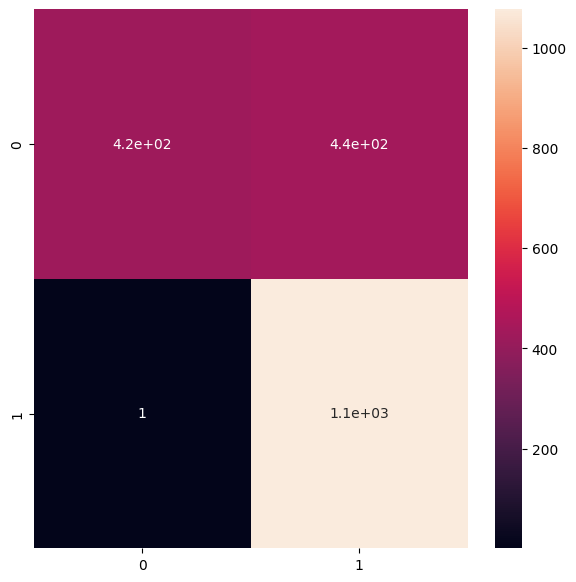

In [49]:
# Representamos la matriz de confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(original, predict)
plt.figure(figsize = (7,7))
sns.heatmap(cm, annot=True)

In [50]:
# Imprimimos el reporte de clasificación

from sklearn.metrics import classification_report

report = classification_report(original,predict, labels = [0,1])
print(report)

              precision    recall  f1-score   support

           0       1.00      0.49      0.66       858
           1       0.71      1.00      0.83      1078

    accuracy                           0.77      1936
   macro avg       0.85      0.75      0.75      1936
weighted avg       0.84      0.77      0.76      1936



In [51]:
# dividir los datos en datos de entrenamiento y de prueba

from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(defect_class_mask_df, test_size=0.2)

In [52]:
# crear una lista separada para imageId, classId y rle para pasar al generador

train_ids = list(X_train.ImageId)
train_class = list(X_train.ClassId)
train_rle = list(X_train.EncodedPixels)

val_ids = list(X_val.ImageId)
val_class = list(X_val.ClassId)
val_rle = list(X_val.EncodedPixels)

In [53]:
from utilities import DataGenerator

# Crear el generador de imágenes

training_generator = DataGenerator(train_ids,train_class, train_rle, train_dir)
validation_generator = DataGenerator(val_ids,val_class,val_rle, train_dir)


In [54]:
def resblock(X, f):


  # Hacemos una copia de la entrada
  X_copy = X

  # Path principal
  # Puedes leer más aquí: https://medium.com/@prateekvishnu/xavier-and-he-normal-he-et-al-initialization-8e3d7a087528

  X = Conv2D(f, kernel_size = (1,1), strides = (1,1), kernel_initializer ='he_normal')(X)
  X = BatchNormalization()(X)
  X = Activation('relu')(X)

  X = Conv2D(f, kernel_size = (3,3), strides =(1,1), padding = 'same', kernel_initializer ='he_normal')(X)
  X = BatchNormalization()(X)

  # Path corto
  # Puedes leer más aquí: https://towardsdatascience.com/understanding-and-coding-a-resnet-in-keras-446d7ff84d33

  X_copy = Conv2D(f, kernel_size = (1,1), strides =(1,1), kernel_initializer ='he_normal')(X_copy)
  X_copy = BatchNormalization()(X_copy)

  # Añadimos el fichero de salida a partir de la combinación de path principal y el corto

  X = Add()([X,X_copy])
  X = Activation('relu')(X)

  return X

In [55]:
# Función para upscale y concatenar los valores

def upsample_concat(x, skip):
  x = UpSampling2D((2,2))(x)
  merge = Concatenate()([x, skip])

  return merge

In [56]:
input_shape = (256,256,1)

#Input tensor shape
X_input = Input(input_shape)

#Stage 1
conv1_in = Conv2D(16,3,activation= 'relu', padding = 'same', kernel_initializer ='he_normal')(X_input)
conv1_in = BatchNormalization()(conv1_in)
conv1_in = Conv2D(16,3,activation= 'relu', padding = 'same', kernel_initializer ='he_normal')(conv1_in)
conv1_in = BatchNormalization()(conv1_in)
pool_1 = MaxPool2D(pool_size = (2,2))(conv1_in)

#Stage 2
conv2_in = resblock(pool_1, 32)
pool_2 = MaxPool2D(pool_size = (2,2))(conv2_in)

#Stage 3
conv3_in = resblock(pool_2, 64)
pool_3 = MaxPool2D(pool_size = (2,2))(conv3_in)

#Stage 4
conv4_in = resblock(pool_3, 128)
pool_4 = MaxPool2D(pool_size = (2,2))(conv4_in)

#Stage 5
conv5_in = resblock(pool_4, 256)

#Upscale stage 1
up_1 = upsample_concat(conv5_in, conv4_in)
up_1 = resblock(up_1, 128)

#Upscale stage 2
up_2 = upsample_concat(up_1, conv3_in)
up_2 = resblock(up_2, 64)

#Upscale stage 3
up_3 = upsample_concat(up_2, conv2_in)
up_3 = resblock(up_3, 32)

#Upscale stage 4
up_4 = upsample_concat(up_3, conv1_in)
up_4 = resblock(up_4, 16)

#Final Output
output = Conv2D(4, (1,1), padding = "same", activation = "sigmoid")(up_4)

model_seg = Model(inputs = X_input, outputs = output )


## Función de pérdidas:

Necesitamos una función de pérdida personalizada para entrenar a este ResUNet: https://github.com/nabsabraham/focal-tversky-unet/blob/master/losses.py


@article{focal-unet,
  title={A novel Focal Tversky loss function with improved Attention U-Net for lesion segmentation},
  author={Abraham, Nabila and Khan, Naimul Mefraz},
  journal={arXiv preprint arXiv:1810.07842},
  year={2018}
}

In [57]:
from utilities import focal_tversky, tversky_loss, tversky

In [58]:
adam = tf.keras.optimizers.Adam(learning_rate=0.05, epsilon=0.1)
model_seg.compile(optimizer = adam, loss = focal_tversky, metrics = [tversky])

In [59]:
# usar la parada temprana para salir del entrenamiento si la pérdida de validación no disminuye incluso después de ciertas epochs (patience)
earlystopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)

# guardar el mejor modelo con menor pérdida de validación
checkpointer = ModelCheckpoint(filepath="resunet-segmentation-weights.weights.h5", verbose=1, save_best_only=True, save_weights_only=True)

In [59]:
history = model_seg.fit(training_generator, epochs=40, validation_data=validation_generator, callbacks=[checkpointer, earlystopping])

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.9497 - tversky: 0.0664

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from None to 0.88720, saving model to resunet-segmentation-weights.weights.h5
287/287 ━━━━━━━━━━━━━━━━━━━━ 711s 2s/step - loss: 0.9319 - tversky: 0.0895 - val_loss: 0.8872 - val_tversky: 0.1470
Epoch 2/40
287/287 ━━━━━━━━━━━━━━━━━━━━ 711s 2s/step - loss: 0.9319 - tversky: 0.0895 - val_loss: 0.8872 - val_tversky: 0.1470
Epoch 2/40
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.7893 - tversky: 0.2681
Epoch 2: val_loss improved from 0.88720 to 0.66665, saving model to resunet-segmentation-weights.weights.h5

Epoch 2: val_loss improved from 0.88720 to 0.66665, saving model to resunet-segmentation-weights.weights.h5
287/287 ━━━━━━━━━━━━━━━━━━━━ 675s 2s/step - loss: 0.7294 - tversky: 0.3406 - val_loss: 0.6666 - val_tversky: 0.4160
Epoch 3/40
287/287 ━━━━━━━━━━━━━━━━━━━━ 675s 2s/step - loss: 0.7294 - tversky: 0.3406 - val_loss: 0.6666 - val_tversky: 0.4160
Epoch 3/40
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.6407 - tversky: 0.4458
Epoch 3: val_loss impro

In [60]:
# Guardamos el modelo para uso futuro

model_json = model_seg.to_json()
with open("resunet-segmentation-model.json","w") as json_file:
  json_file.write(model_json)

In [60]:
from utilities import focal_tversky, tversky_loss, tversky

with open('resunet-segmentation-model.json', 'r') as json_file:
    json_savedModel= json_file.read()

# Cargar el modelo
model_seg = tf.keras.models.model_from_json(json_savedModel, custom_objects={'focal_tversky': focal_tversky, 'tversky': tversky})
model_seg.load_weights('resunet-segmentation-weights.weights.h5')
adam = tf.keras.optimizers.Adam(learning_rate = 0.05, epsilon = 0.1)
model_seg.compile(optimizer = adam, loss = focal_tversky, metrics = [tversky])

In [61]:
# Datos del conjunto de test para la tarea de segmentación

test_df = pd.read_csv('test.csv')


In [62]:
test_df


,ImageId,ClassId,EncodedPixels
0,0ca915b9f.jpg,3,188383 3 188637 5 188892 6 189148 5 189403 6 1...
1,7773445b7.jpg,3,75789 33 76045 97 76300 135 76556 143 76811 15...
2,5e0744d4b.jpg,3,120323 91 120579 182 120835 181 121091 181 121...
3,6ccde604d.jpg,3,295905 32 296098 95 296290 159 296483 222 2967...
4,16aabaf79.jpg,1,352959 24 353211 28 353465 31 353719 33 353973...
...,...,...,...
633,a4334d7da.jpg,4,11829 7 12073 20 12317 32 12566 40 12821 41 13...
634,418e47222.jpg,3,46340 43 46596 127 46852 211 47108 253 47364 2...
635,817a545aa.jpg,3,206529 64 206657 4518 211201 179 211457 128 21...
636,caad490a5.jpg,3,59631 10 59867 30 60103 50 60339 69 60585 79 6...


In [63]:
test_df.ImageId

0      0ca915b9f.jpg
1      7773445b7.jpg
2      5e0744d4b.jpg
3      6ccde604d.jpg
4      16aabaf79.jpg
           ...      
633    a4334d7da.jpg
634    418e47222.jpg
635    817a545aa.jpg
636    caad490a5.jpg
637    a5e9195b6.jpg
Name: ImageId, Length: 638, dtype: object

In [64]:
from utilities import prediction

# Hacemos la predicción
image_id, defect_type, mask = prediction(test_df, model, model_seg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━

In [65]:
# Creamos el dataframe para el resultado
df_pred= pd.DataFrame({'ImageId': image_id,'EncodedPixels': mask,'ClassId': defect_type})
df_pred.head()

,ImageId,EncodedPixels,ClassId
0,0ca915b9f.jpg,178634 2 178890 2 179146 2 179402 2 179658 2 1...,3
1,7773445b7.jpg,82678 7 82686 2 82934 7 82942 2 83190 7 83198 ...,3
2,5e0744d4b.jpg,53676 6 53932 6 54188 6 54444 6 54700 6 54956 ...,3
3,6ccde604d.jpg,295375 13 295390 28 295631 13 295646 28 295887...,3
4,16aabaf79.jpg,357867 4 358123 4 358379 4 358635 4 358891 4 3...,3


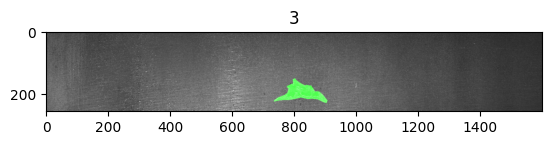

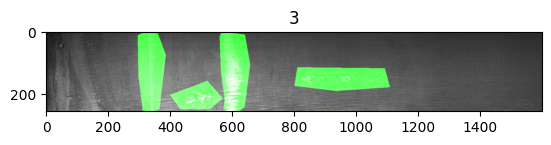

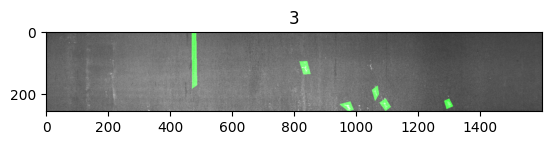

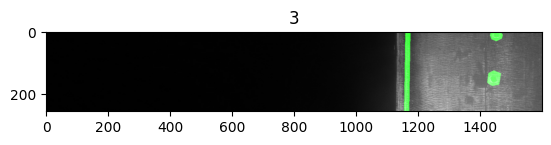

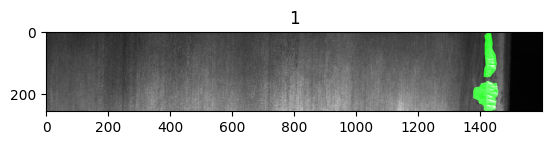

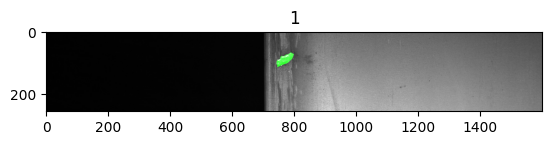

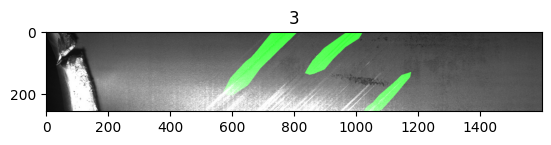

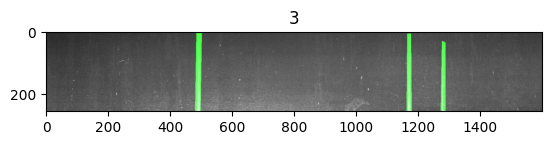

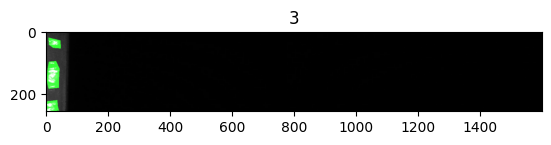

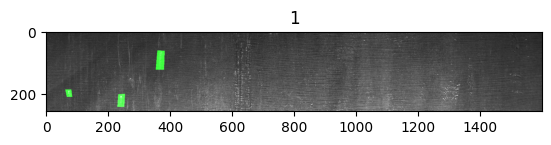

In [66]:
# Vamos a mostrar las imágenes junto con sus máscaras originales (ground truth)
for i in range(10):

  # leer las imágenes usando opencv y convertirlas a formato rgb
  img = io.imread(os.path.join(train_dir,test_df.ImageId[i]))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # Obtener máscara para la imagen de rle
  mask = rle2mask(test_df.EncodedPixels[i],img.shape[0],img.shape[1])

  img[mask == 1,1] = 255
  plt.figure()
  plt.title(test_df.ClassId[i])
  plt.imshow(img)

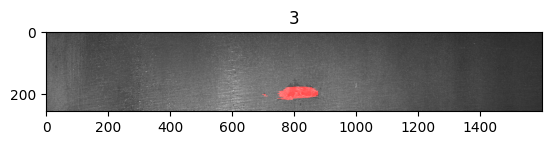

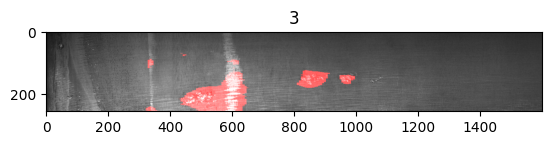

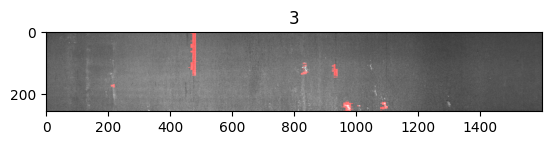

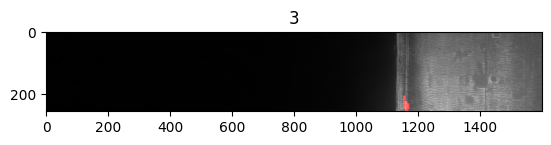

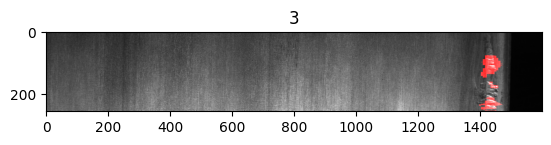

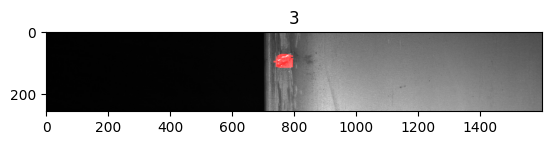

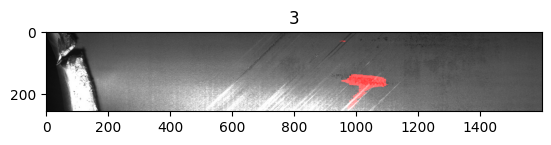

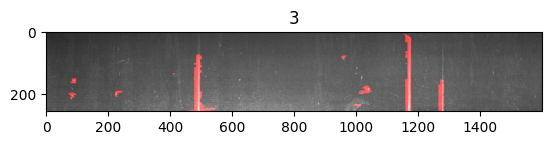

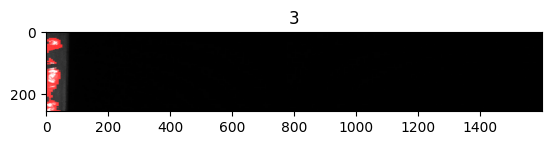

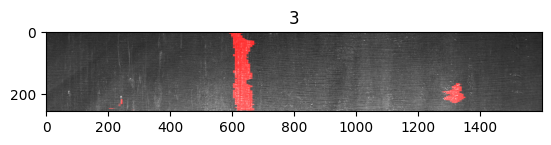

In [67]:
# visualizar los resultados (predicciones del modelo)

directory = "train_images"

for i in range(10):

  # leer las imágenes usando opencv y convertirlas a formato rgb
  img = io.imread(os.path.join(directory,df_pred.ImageId[i]))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

   # Obtener máscara para la imagen de rle
  mask = rle2mask(df_pred.EncodedPixels[i],img.shape[0],img.shape[1])

  img[mask == 1,0] = 255
  plt.figure()
  plt.title(df_pred.ClassId[i])
  plt.imshow(img)